In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import data_processing
from data_processing import vertical_profile_plot as vpp
from importlib import reload

In [2]:
h2o_data = xr.open_dataset('ACEFTS_L2_v5p2_H2O.nc')
h2o_flags = xr.open_dataset('ACEFTS_L2_v5p2_flags_H2O.nc')

In [3]:
h2o_data = h2o_data.set_index(index=['orbit', 'sunset_sunrise'])
h2o_flags = h2o_flags.set_index(index=['orbit', 'sunset_sunrise'])

In [4]:
years = h2o_data['year'].values
months = h2o_data['month'].values
days = h2o_data['day'].values
hours = h2o_data['hour'].values
times = pd.to_datetime({
    'year': years,
    'month': months,
    'day': days,
    'hour': hours
})

In [5]:
bad_profile_indices = []
for i in range(0, len(times)-1):
    orbit_number = h2o_data['orbit'][i].values
    ss = h2o_data['sunset_sunrise'][i].values

    try:
        flag_profile = h2o_flags['quality_flag'].sel(orbit=orbit_number, sunset_sunrise=ss).values
        if ((flag_profile != 0) & (flag_profile != 8) & (flag_profile != 9)).any():
            bad_profile_indices.append(i)
    except KeyError:
        print(f"Skipping missing orbit/sunset_sunrise pair: orbit={orbit_number}, sunset_sunrise={ss}")
        continue


Skipping missing orbit/sunset_sunrise pair: orbit=110807.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=110955.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111363.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111430.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111444.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111445.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111466.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112226.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112505.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112518.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112525.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112526.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=11

In [6]:
print(len(bad_profile_indices))

1276


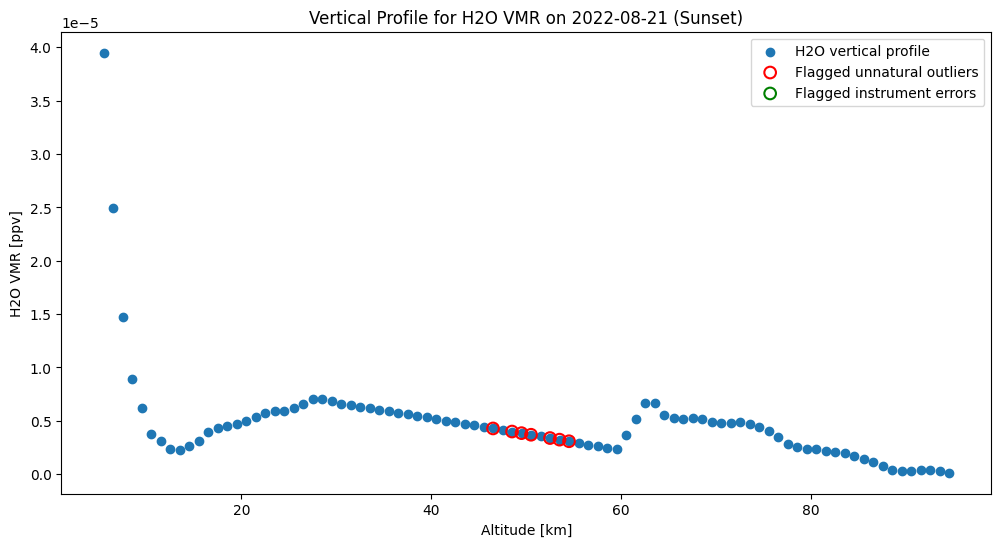

In [6]:
bad_profile_indices = np.array(bad_profile_indices)
date_index = np.random.choice(bad_profile_indices)
vpp('H2O', h2o_data, h2o_flags, date_index)

In [8]:
key_date = date_index
print(key_date)

13097


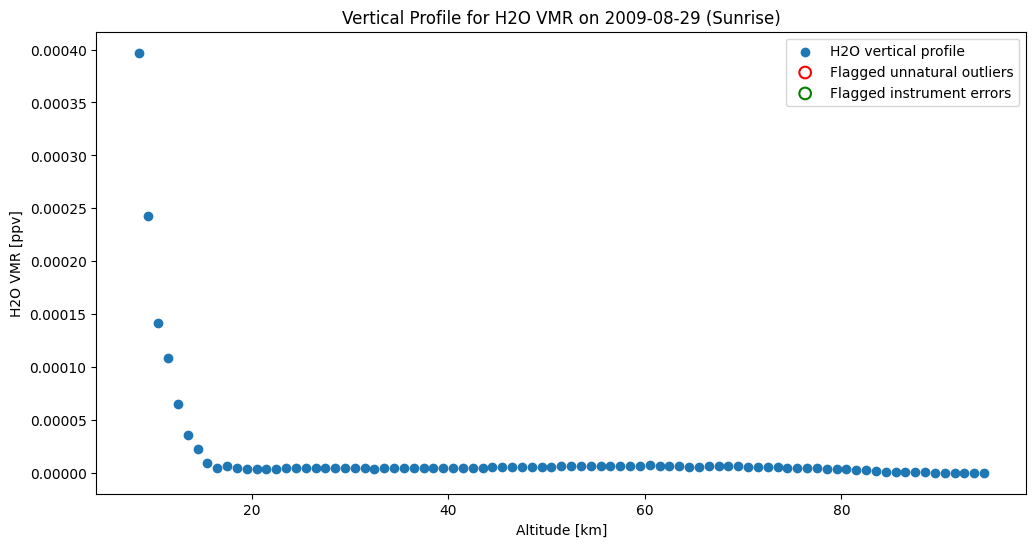

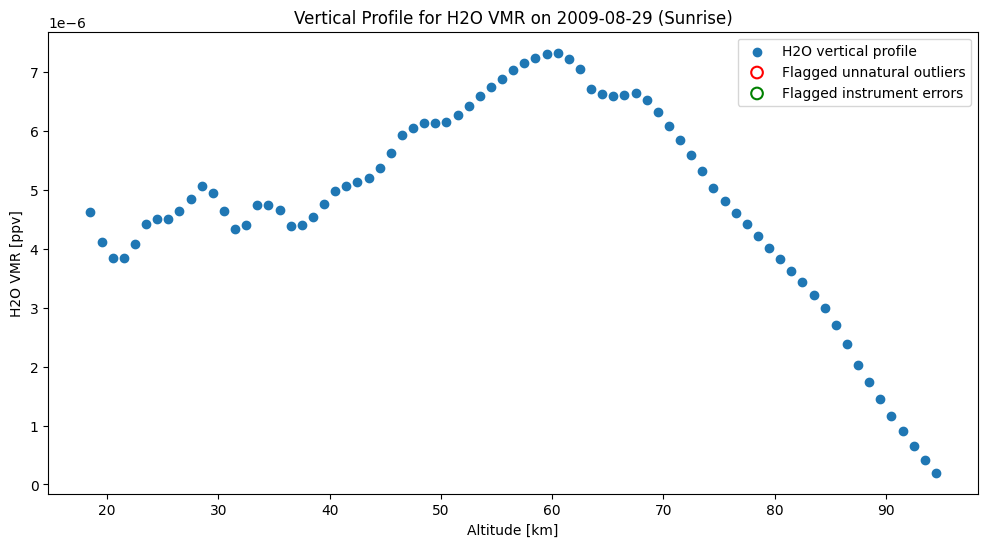

In [9]:
vpp('H2O', h2o_data, h2o_flags, date_index-1)
vpp('H2O', h2o_data, h2o_flags, date_index+1)

63767

In [10]:
latitudes = h2o_data['latitude'].values


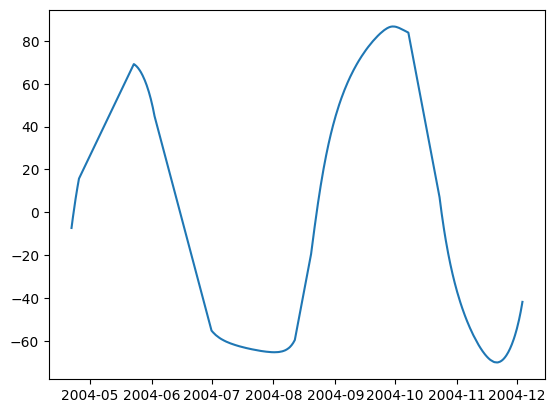

In [11]:
plt.plot(times[:1000], latitudes[:1000])

In [80]:
date_index = np.random.choice(bad_profile_indices)

9528


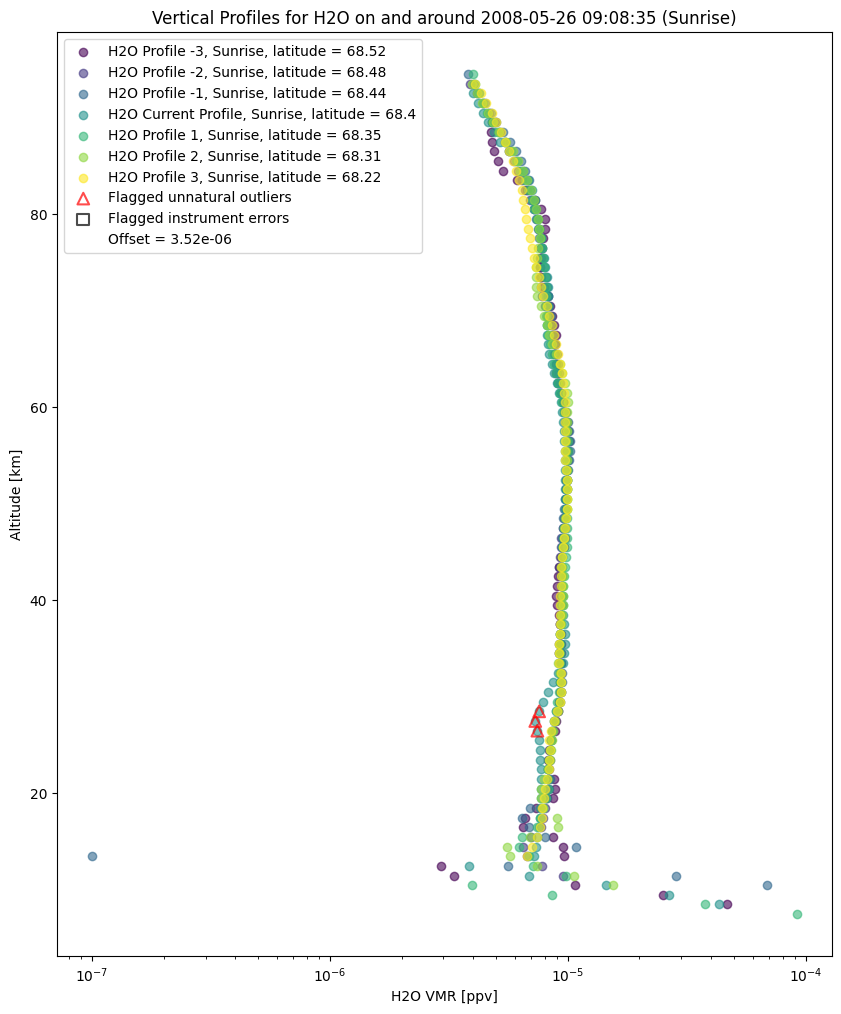

In [24]:
reload(vertical_gas_profile_plot)
from vertical_gas_profile_plot import vertical_profile_plot as vpp
date_index = np.random.choice(bad_profile_indices)
print(date_index)
vpp('H2O', h2o_data, h2o_flags, date_index, 5)

In [ ]:
orbit = h2o_data['orbit'][date_index].values
ss = h2o_data['sunset_sunrise'][date_index].values

flag_profile = h2o_flags['quality_flag'].sel(orbit=orbit, sunset_sunrise=ss).values

In [108]:
print(times[date_index])

2023-01-14 05:10:59.009999998


In [196]:
def plot_single_profile(index, molecule_data, flag_data, add_legend_labels=True):
    if index is None:
        return  # Skip if no profile exists

    # Extract relevant data
    orbit_number = molecule_data['orbit'][index].values
    ss = molecule_data['sunset_sunrise'][index].values
    if ss in [0,2]:
        occultation_type = 'Sunset'
    else:
        occultation_type = 'Sunrise'
    flags_profile = flag_data['quality_flag'].sel(orbit=orbit_number, sunset_sunrise=ss).values
    molecule_vmr = molecule_data['H2O'][index, :].values.flatten()
    latitude = molecule_data['latitude'][index].values

    # Masking
    mask = (flags_profile != 9) & (flags_profile != 8)
    molecule_vmr = molecule_vmr[mask]
    altitude = molecule_data['altitude'].values[mask]
    #print(np.column_stack([molecule_vmr, altitude]))
    flags_profile = flags_profile[mask]

    # Identify flagged values
    outlier_mask = (flags_profile == 4) | (flags_profile == 5) | (flags_profile == 6)
    #print(outlier_mask)
    outlier_vmr = molecule_vmr[outlier_mask]
    # print(outlier_vmr)
    outlier_altitude = altitude[outlier_mask]
    #print("Outlier Altitude Range:", outlier_altitude.min(), outlier_altitude.max())
    inst_error_mask = (flags_profile == 7)
    error_vmr = molecule_vmr[inst_error_mask]
    error_altitude = altitude[inst_error_mask]

    # Plot
    plt.scatter(
        molecule_vmr, altitude,
        label=f"'H2O', {occultation_type}, latitude = {latitude}",
        alpha=0.6
    )
    if add_legend_labels:
        plt.scatter(
            outlier_vmr, outlier_altitude,
            marker = '^' ,facecolors="none", edgecolors="red", s=70, linewidths=1.5, label="Flagged unnatural outliers", alpha=0.7
        )
        plt.scatter(
            error_vmr, error_altitude,
            marker = 's',facecolors="none", edgecolors="black", s=70, linewidths=1.5, label="Flagged instrument errors", alpha = 0.7
        )
    else:
        plt.scatter(
            outlier_vmr, outlier_altitude,
            marker = '^',facecolors="none", edgecolors="red", s=70, linewidths=1.5, alpha = 0.7
        )
        plt.scatter(
            error_vmr, error_altitude,
            marker= 's', facecolors="none", edgecolors="black", s=70, linewidths=1.5, alpha = 0.7
        )
    plt.legend()


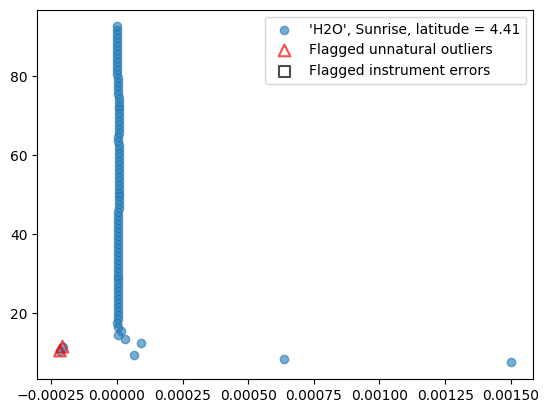

In [197]:
plot_single_profile(date_index, h2o_data, h2o_flags)